# Подготовка шаблона


In [ ]:
%load_ext autoreload
%autoreload 2

import os
import io
import cv2
import json
import numpy as np

from PIL import Image
from IPython.display import Image as IPImage, display
import matplotlib.pyplot as plt

from utils import (
    generate_template,
    overlay_character,
    template_meta,
    build_triangulation,
    draw_triangulation,
    markup_skeleton,
    save_skeleton,
    animate_character,
    render_svg,

    preview_motion,
    build_arap_mesh,
    draw_arap_mesh,
    animate_arap
)


# --- параметры шаблона ---
CANVAS_SIZE = (1240, 1754)   # A4 @ 150 DPI (h, w)
MARKER_PX = 80
MARGIN = 60
CONTENT_PAD = 10

TITLE = "Sketch Factory"
OUTPUT_DIR = "output"

CHAR_ID = "003"
CHAR_DIR = f"templates/{CHAR_ID}"

meta = template_meta(CANVAS_SIZE, MARKER_PX, MARGIN, CONTENT_PAD)
print(f"Canvas:      {CANVAS_SIZE[1]}x{CANVAS_SIZE[0]}")
print(f"Drawing bbox: {meta['drawing_bbox']}")
print(f"Markers:      {meta['marker_centers']}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Canvas:      1754x1240
Drawing bbox: [150, 150, 1454, 940]
Markers:      [[100.0, 100.0], [1654.0, 100.0], [1654.0, 1140.0], [100.0, 1140.0]]


## Пустой А4

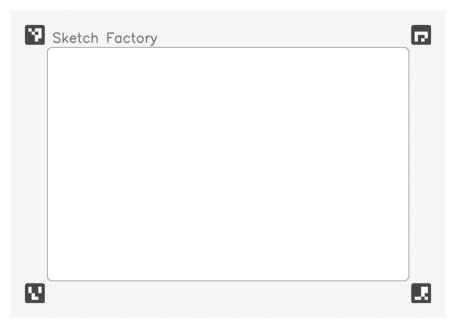

Сохранено: output\template.png


In [64]:
result = generate_template(
    output_path=f"{OUTPUT_DIR}/template.png",
    canvas_size=CANVAS_SIZE,
    marker_px=MARKER_PX,
    margin=MARGIN,
    content_pad=CONTENT_PAD,
    title=TITLE,
)

plt.figure(figsize=(7, 4))
plt.imshow(cv2.cvtColor(result["template"], cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

print(f"Сохранено: {result['template_path']}")

## Наложение персонажа PNG

image_rect: [345, 244, 1064, 752]


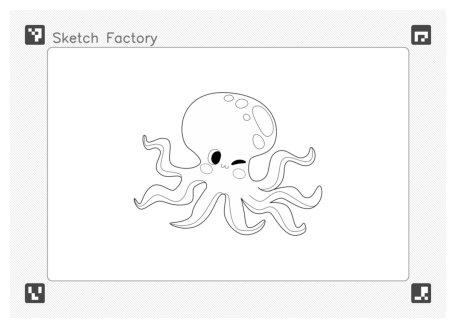

In [65]:
# SVG → шаблон для печати
result_char = overlay_character(
    template_path=f"{OUTPUT_DIR}/template.png",
    svg_path=f"{CHAR_DIR}/mask.svg",
    output_path=f"{CHAR_DIR}/template.png",
    content_scale=0.8,
    canvas_size=CANVAS_SIZE,
    marker_px=MARKER_PX,
    margin=MARGIN,
    content_pad=CONTENT_PAD,
)

print(f"image_rect: {result_char['image_rect']}")

plt.figure(figsize=(7, 4))
plt.imshow(cv2.cvtColor(result_char["template"], cv2.COLOR_BGR2RGB))
plt.axis("off"); plt.show()

## Анимация

In [ ]:
# img = render_svg(f"{CHAR_DIR}/mask.svg")
# tmp_png = f"{CHAR_DIR}/mask_render.png"
# cv2.imwrite(tmp_png, cv2.cvtColor(img, cv2.COLOR_RGBA2BGRA))

# keypoints = markup_skeleton(tmp_png)
# os.remove(tmp_png)  # убираем временный файл

# with open(f"{CHAR_DIR}/skeleton.json", "w") as f:
#     json.dump({"image_size": [img.shape[1], img.shape[0]],
#                "keypoints": keypoints, "char_id": CHAR_ID}, f, indent=2)
# print(f"Сохранено {len(keypoints)} точек: {list(keypoints.keys())}")

Сохранено 34 точек: ['f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11', 'f12', 'f13', 'f14', 'f15', 'f16', 'f17', 'f18', 'f19', 'f20', 'f21', 'h1', 'h2', 'h3', 'h4', 'h5', 'h6', 'h7', 'h8', 'h9', 'h10', 'b1', 'b2', 'b3']


In [68]:
with open(f"{CHAR_DIR}/skeleton.json") as f:
    keypoints = json.load(f)["keypoints"]
print(f"Загружено {len(keypoints)} точек: {list(keypoints.keys())}")

Загружено 34 точек: ['f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11', 'f12', 'f13', 'f14', 'f15', 'f16', 'f17', 'f18', 'f19', 'f20', 'f21', 'h1', 'h2', 'h3', 'h4', 'h5', 'h6', 'h7', 'h8', 'h9', 'h10', 'b1', 'b2', 'b3']


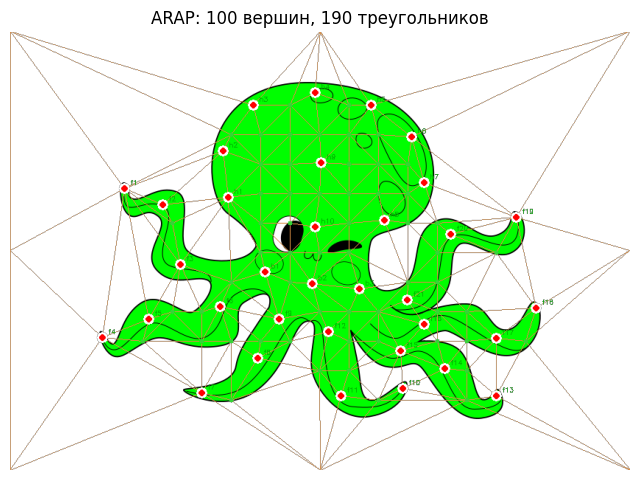

In [69]:
img = cv2.cvtColor(render_svg(f"{CHAR_DIR}/mask.svg"), cv2.COLOR_RGBA2BGRA)
th, tw = img.shape[:2]
V0, tri, n_kp, n_int, kp_names, h_idx = build_arap_mesh(
    keypoints, tw, th, img[:, :, 3])

vis = draw_arap_mesh(img, V0, tri, n_kp, kp_names, n_int)
plt.figure(figsize=(8, 6))
plt.imshow(vis); plt.axis("off")
plt.title(f"ARAP: {len(V0)} вершин, {len(tri.simplices)} треугольников")
plt.show()

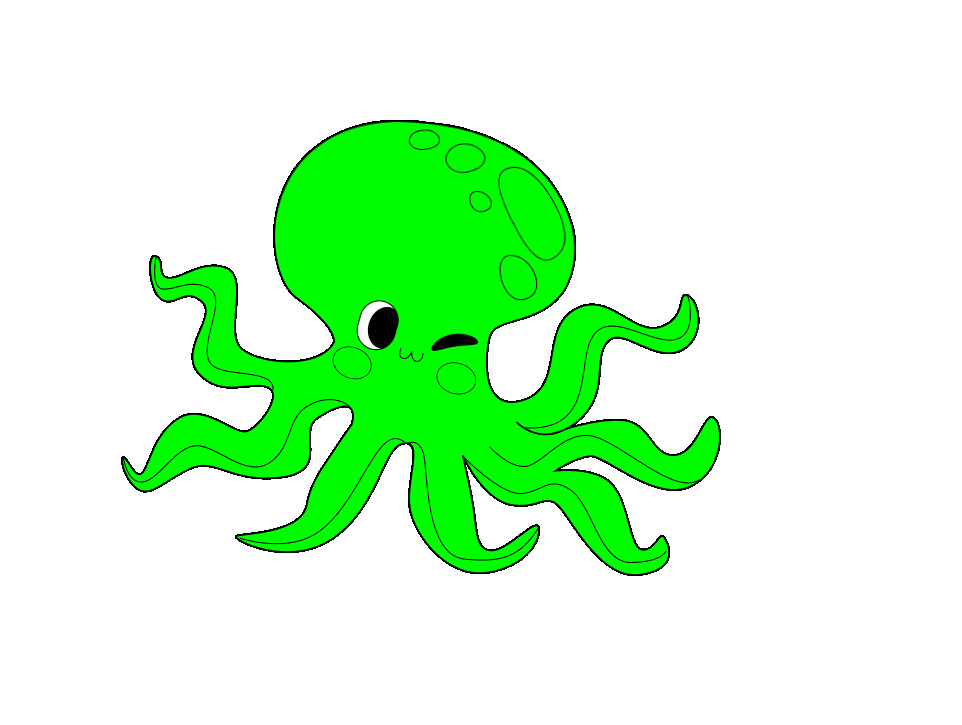

In [78]:
with open(f"{CHAR_DIR}/animation.json") as f:
    motion_cfg = json.load(f)

FPS = 30
DURATION = 3        # секунды
PAD = (50, 80, 0, 120)  # top, bottom, left, right — запас для движения

img = cv2.cvtColor(render_svg(f"{CHAR_DIR}/mask.svg"), cv2.COLOR_RGBA2BGRA)
frames = animate_arap(img, keypoints, motion_cfg,
                      fps=FPS, duration=DURATION, pad=PAD)

pil_frames = [Image.fromarray(cv2.cvtColor(f, cv2.COLOR_BGRA2RGBA)) for f in frames]
buf = io.BytesIO()
pil_frames[0].save(buf, format="GIF", save_all=True, append_images=pil_frames[1:],
                   duration=1000 // FPS, loop=0, disposal=2)
display(IPImage(data=buf.getvalue(), width=500))

# Движение по миру

Паттерн: up_left


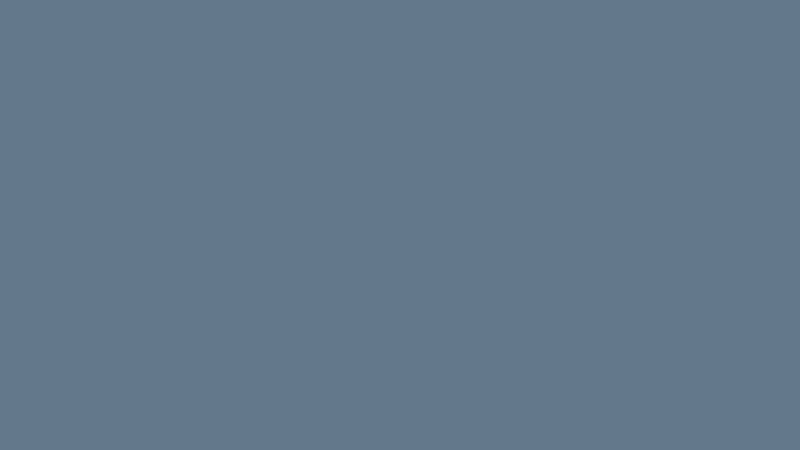

In [83]:
with open(f"{CHAR_DIR}/motion.json") as f:
    motion_patterns = json.load(f)

pat_name = "up_left"
preview = preview_motion(frames, motion_patterns[pat_name], fps=FPS)

buf = io.BytesIO()
preview[0].save(buf, format="GIF", save_all=True,
                append_images=preview[1:],
                duration=1000 // FPS, loop=0)
print(f"Паттерн: {pat_name}")
display(IPImage(data=buf.getvalue(), width=600))